# this notebook assumes GitHub repo is the source of ALL up-to-date routes for liquids

In [1]:
import pygsheets # use 'pip install pygsheets', not maintained with conda
import pandas
import datetime
import geopandas
import shapely
import pathlib
import pyogrio
import json

In [2]:
geopandas.__version__

'0.14.0+83.g3151ef4'

# pipelines

### comment out appropriate final lines to only publish oil or gas

In [3]:
file_output = "liquid" # liquid pipelines (crude oil, NGL, other options like CO2)
#file_output = "gas" # gas pipelines (natural gas, hydrogen)

In [4]:
gc = pygsheets.authorize(service_account_env_var='GDRIVE_API_CREDENTIALS')
spreadsheet = gc.open_by_key('1foPLE6K-uqFlaYgLPAUxzeXfDO5wOOqE7tibNHeqTek') # current version

gas_pipes = spreadsheet.worksheet('title','Gas pipelines').get_as_df(start='A3')
liquid_pipes = spreadsheet.worksheet('title','Oil/NGL pipelines').get_as_df(start='A3')

In [5]:
gas_pipes.Fuel.unique()

array(['Gas', 'Oil', 'Hydrogen', ''], dtype=object)

In [6]:
liquid_pipes.Fuel.unique()

array(['Oil', 'Oil products (only)', 'Oil, NGL', 'NGL',
       'NGL, oil products', 'Naphtha (only)', 'Oil, NGL, naphtha', 'CO2',
       'Gas', 'Naphtha, oil products', ''], dtype=object)

### remove all pipeline properties except pipeline name, segment name, projectid, route information

In [7]:
keep_these_columns = ['PipelineName',
                      'SegmentName',
                      'ProjectID',
                      'Status',
                      'Fuel',
                      'RouteType',
                      'RouteAccuracy',
                      'RouteNotes']
gas_pipes = gas_pipes[keep_these_columns]
liquid_pipes = liquid_pipes[keep_these_columns]

In [8]:
#pandas.concat([gas_pipes,liquid_pipes], ignore_index=True)
if file_output=="gas":
    all_pipes = gas_pipes.copy()
if file_output=="liquid":
    all_pipes = liquid_pipes.copy()

In [601]:
all_pipes.head()

,PipelineName,SegmentName,ProjectID,Status,Fuel,RouteType,RouteAccuracy,RouteNotes
0,Double E Pipeline Project,,P0061,operating,Gas,Mapped route (at any accuracy),high,http://www.doubleepipeline.com/Content/Maps/Do...
1,Acadian Gas Pipeline System,,P0143,operating,Gas,Mapped route (at any accuracy),low,https://www.enterpriseproducts.com/operations/...
2,Algonquin Gas Transmission Pipeline,Access Northeast Gas Pipeline,P0144,cancelled,Gas,Mapped route (at any accuracy),low,
3,Access South Gas Pipeline,,P0145,operating,Gas,Mapped route (at any accuracy),low,
4,Alaska Gas Pipeline,,P0146,cancelled,Gas,Mapped route (at any accuracy),low,


## clean up pipelines

ONLY INCLUDE ROUTES WITH TEXT IN THE ROUTEACCURACY FIELD  
anything that doesn't have this field out is not, in Baird's view, a completed pipeline

In [602]:
# pipelines cleanup
# if the RouteAccuracy is blank, that means we don't want it included in the database
all_pipes = all_pipes.loc[all_pipes.RouteAccuracy!='']

In [603]:
all_pipes.shape

(3794, 8)

## merge all GeoJSON files into one

In [604]:
geojson_path = '/Users/baird/Dropbox/_git_ALL/_github-repos-gem/'+\
'GOIT-GGIT-pipeline-routes/data/individual-routes/'+file_output+'-pipelines/'

geojson_route_files = list(
    pathlib.Path(
        geojson_path
    ).rglob('?????.geojson')
)

In [605]:
geojson_route_files.__len__()

3794

In [606]:
geojson_projectids = [str(i).split('/')[-1][:5] for i in geojson_route_files]

## in Google Sheet but missing in repo
* you may need to create an empty file for this

In [607]:
set(all_pipes.ProjectID.tolist())-set(geojson_projectids)

set()

## in repo but missing in Google Sheet
* in this case, you likely need to change RouteAccuracy...

In [608]:
set(geojson_projectids)-set(all_pipes.ProjectID.tolist())

set()

# assemble all of these into the proper geodataframe format

In [609]:
for idx,pid in enumerate(all_pipes.ProjectID.tolist()):
    try:
        file = geojson_path + pid + '.geojson'
        file_gdf = geopandas.read_file(file)
        file_geometry_dissolved = file_gdf.dissolve().geometry
        all_pipes.loc[all_pipes.ProjectID==pid,'geometry'] = file_geometry_dissolved[0]
    except:
        print(pid," geojson file either doesn't exist or has bad geometry")

In [610]:
# remove any NaN geometries that were part of the exception above
all_pipes = all_pipes.loc[~all_pipes.geometry.isnull()]

look at the geometries more closely

    P6494 <class 'shapely.geometry.multilinestring.MultiLineString'>
    P6496 <class 'shapely.geometry.linestring.LineString'>
    P6497 <class 'shapely.geometry.collection.GeometryCollection'>

In [611]:
tf_is_empty = pandas.Series([row.geometry.is_empty for idx,row in all_pipes.iterrows()])
all_pipes_remove_empty = all_pipes[~tf_is_empty.values]

In [612]:
all_pipes_gdf = geopandas.GeoDataFrame(all_pipes, geometry=all_pipes.geometry)

<Axes: >

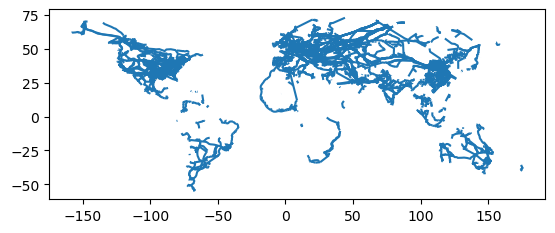

In [613]:
all_pipes_gdf.geometry.plot()

In [614]:
filename = '../data/GEM-'+file_output+'-pipelines-for-GitHub-'+str(datetime.date.today())+'.geojson'
all_pipes_gdf.set_index('ProjectID').to_file(filename, driver='GeoJSON')
#all_pipes_df_to_save_gdf[['ProjectID']].to_file(filename, driver='GeoJSON')
print('saved as', filename)

saved as ../data/GEM-gas-pipelines-for-GitHub-2024-04-19.geojson
